In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('DataSets/prisoners.csv')

# Display the first five rows
print("First five rows:\n", df.head())

# Display the last five rows
print("\nLast five rows:\n", df.tail())


First five rows:
             STATE/UT  YEAR  No. of Inmates benefitted by Elementary Education  \
0     Andhra Pradesh  2013                                               9480   
1  Arunachal Pradesh  2013                                                  0   
2              Assam  2013                                                676   
3              Bihar  2013                                               1693   
4        Chhatisgarh  2013                                               1664   

   No. of Inmates benefitted by Adult Education  \
0                                         13758   
1                                             0   
2                                           750   
3                                          3013   
4                                          1803   

   No. of Inmates benefitted by Higher Education  \
0                                            672   
1                                              0   
2                               

In [5]:

# Use describe() to get summary statistics
print("Summary statistics:\n", df.describe())

# Find the number of columns
print("\nNumber of columns:", len(df.columns))

# Identify rows where inmates count is zero

# Columns that hold beneficiary counts
benefit_cols = [
    'No. of Inmates benefitted by Elementary Education',
    'No. of Inmates benefitted by Adult Education',
    'No. of Inmates benefitted by Higher Education',
    'No. of Inmates benefitted by Computer Course'
]

zero_any = df.loc[
    (df[benefit_cols] == 0).any(axis=1) & ~(df[benefit_cols] == 0).all(axis=1),
    ['STATE/UT', 'YEAR'] + benefit_cols
]
print("Rows with AT LEAST ONE zero (but not all):\n", zero_any)



Summary statistics:
          YEAR  No. of Inmates benefitted by Elementary Education  \
count    35.0                                          35.000000   
mean   2013.0                                        1057.914286   
std       0.0                                        2078.196777   
min    2013.0                                           0.000000   
25%    2013.0                                           0.000000   
50%    2013.0                                         167.000000   
75%    2013.0                                        1294.500000   
max    2013.0                                        9480.000000   

       No. of Inmates benefitted by Adult Education  \
count                                     35.000000   
mean                                    1534.857143   
std                                     3022.110503   
min                                        0.000000   
25%                                        6.500000   
50%                                 

In [6]:
# Create a new column -’total_benefitted’ that is a sum of inmates benefitted through all modes.


import pandas as pd

# Load the dataset
df = pd.read_csv('DataSets/prisoners.csv')

# Create a new column 'total_benefitted' as the sum of all four numeric columns
df['total_benefitted'] = df[
    [
        'No. of Inmates benefitted by Elementary Education',
        'No. of Inmates benefitted by Adult Education',
        'No. of Inmates benefitted by Higher Education',
        'No. of Inmates benefitted by Computer Course'
    ]
].sum(axis=1)

# Display the updated DataFrame
print(df.head())


            STATE/UT  YEAR  No. of Inmates benefitted by Elementary Education  \
0     Andhra Pradesh  2013                                               9480   
1  Arunachal Pradesh  2013                                                  0   
2              Assam  2013                                                676   
3              Bihar  2013                                               1693   
4        Chhatisgarh  2013                                               1664   

   No. of Inmates benefitted by Adult Education  \
0                                         13758   
1                                             0   
2                                           750   
3                                          3013   
4                                          1803   

   No. of Inmates benefitted by Higher Education  \
0                                            672   
1                                              0   
2                                             14  

In [7]:

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('DataSets/prisoners.csv')

# Columns that hold beneficiary counts
benefit_cols = [
    'No. of Inmates benefitted by Elementary Education',
    'No. of Inmates benefitted by Adult Education',
    'No. of Inmates benefitted by Higher Education',
    'No. of Inmates benefitted by Computer Course'
]

# (Optional) add per-row total first, useful for computing a grand total later
df['total_benefitted'] = df[benefit_cols].sum(axis=1)

# Build the totals row (sum across all states/UTs for each beneficiary column)
totals_row = {
    'STATE/UT': 'totals',
    'YEAR': np.nan,  # or '' if you prefer an empty string
}
totals_row.update(df[benefit_cols].sum().to_dict())

# Include grand total across modes (sum of per-row totals)
totals_row['total_benefitted'] = df['total_benefitted'].sum()

# Append the totals row to the bottom of the DataFrame
df_with_totals = pd.concat([df, pd.DataFrame([totals_row])], ignore_index=True)

# Display the last few rows to verify the new 'totals' row
print(df_with_totals.tail())


       STATE/UT    YEAR  No. of Inmates benefitted by Elementary Education  \
31  Daman & Diu  2013.0                                                  0   
32        Delhi  2013.0                                               1458   
33  Lakshadweep  2013.0                                                  0   
34  Pondicherry  2013.0                                                  0   
35       totals     NaN                                              37027   

    No. of Inmates benefitted by Adult Education  \
31                                             0   
32                                          1187   
33                                             0   
34                                             0   
35                                         53720   

    No. of Inmates benefitted by Higher Education  \
31                                              0   
32                                            908   
33                                              0   
34    

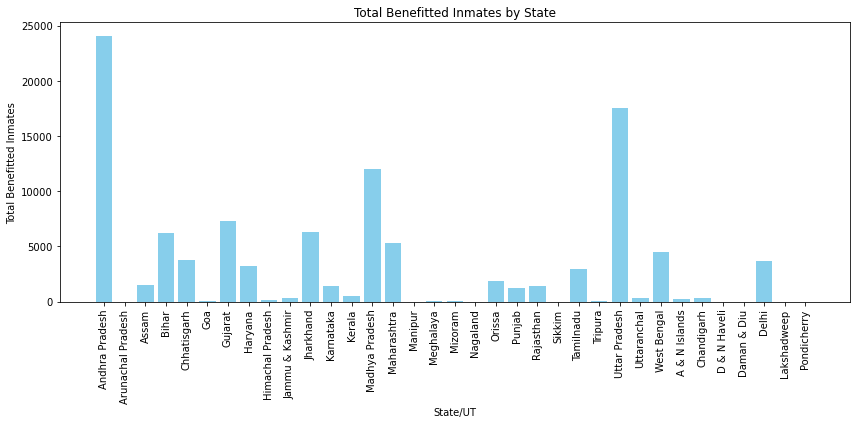

State with maximum beneficiaries: Andhra Pradesh (24080)


In [9]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('DataSets/prisoners.csv')

# Compute total beneficiaries per state
df['total_benefitted'] = df[
    [
        'No. of Inmates benefitted by Elementary Education',
        'No. of Inmates benefitted by Adult Education',
        'No. of Inmates benefitted by Higher Education',
        'No. of Inmates benefitted by Computer Course'
    ]
].sum(axis=1)

# Create bar plot
plt.figure(figsize=(12, 6))
plt.bar(df['STATE/UT'], df['total_benefitted'], color='skyblue')
plt.xticks(rotation=90)
plt.xlabel('State/UT')
plt.ylabel('Total Benefitted Inmates')
plt.title('Total Benefitted Inmates by State')
plt.tight_layout()
plt.show()

# Identify state with maximum beneficiaries
max_state = df.loc[df['total_benefitted'].idxmax(), 'STATE/UT']
max_value = df['total_benefitted'].max()
print(f"State with maximum beneficiaries: {max_state} ({max_value})")
